In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: seaborn styling
sns.set_theme()

# Load the Titanic dataset
titanic_file = "https://milliams.com/courses/data_analysis_python/titanic.csv"
titanic = pd.read_csv(titanic_file)

# Quick look at the data
titanic.head()


,name,gender,age,class,embarked,country,ticketno,fare,sibsp,parch,survived
0,"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0.0,0.0,no
1,"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0.0,2.0,no
2,"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,1.0,1.0,no
3,"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1.0,1.0,yes
4,"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,0.0,0.0,yes


In [2]:
# Average age of all people on board
avg_age_all = titanic["age"].mean()
print("Average age of all people:", avg_age_all)

# Filter only males
males = titanic[titanic["gender"] == "male"]

# Average age of males
avg_age_males = males["age"].mean()
print("Average age of males:", avg_age_males)


Average age of all people: 30.436734693877504
Average age of males: 30.83231351981346


In [3]:
# People in 3rd class
third_class = titanic[titanic["class"] == "3rd"]
third_class.head()

# Only passengers (exclude crew and staff)
passengers = titanic[titanic["class"].isin(["1st", "2nd", "3rd"])]
passengers.head()


,name,gender,age,class,embarked,country,ticketno,fare,sibsp,parch,survived
0,"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0.0,0.0,no
1,"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0.0,2.0,no
2,"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,1.0,1.0,no
3,"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1.0,1.0,yes
4,"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,0.0,0.0,yes


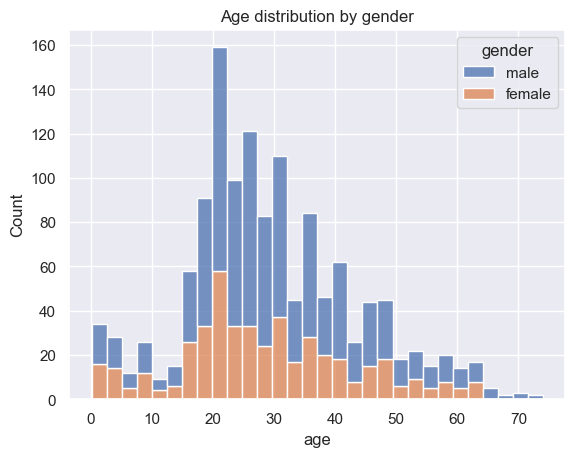

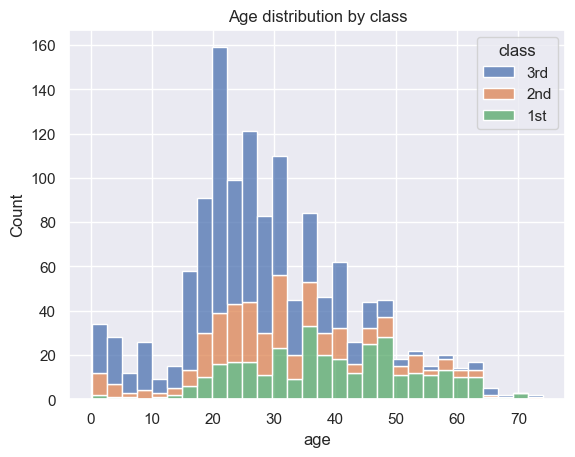

In [4]:
# Histogram of ages by gender
sns.histplot(data=passengers, x="age", hue="gender", multiple="stack", bins=30)
plt.title("Age distribution by gender")
plt.show()

# Distribution of ages by class
sns.histplot(data=passengers, x="age", hue="class", multiple="stack", bins=30)
plt.title("Age distribution by class")
plt.show()


In [5]:
# Percentage survived within each class
survival_rate = passengers.groupby("class")["survived"].value_counts(normalize=True).unstack() * 100
survival_rate


survived,no,yes
class,,
1st,37.962963,62.037037
2nd,58.450704,41.549296
3rd,74.471086,25.528914


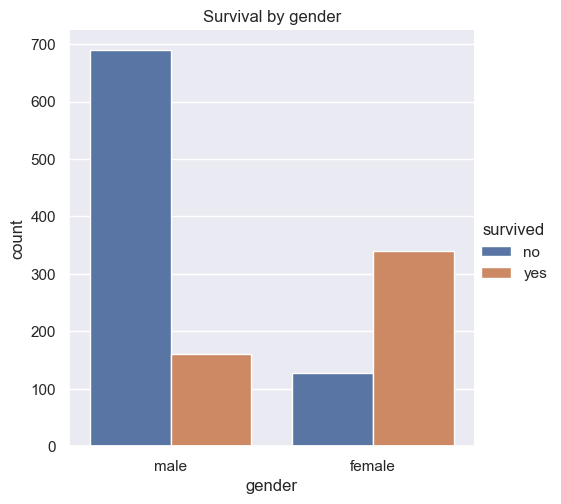

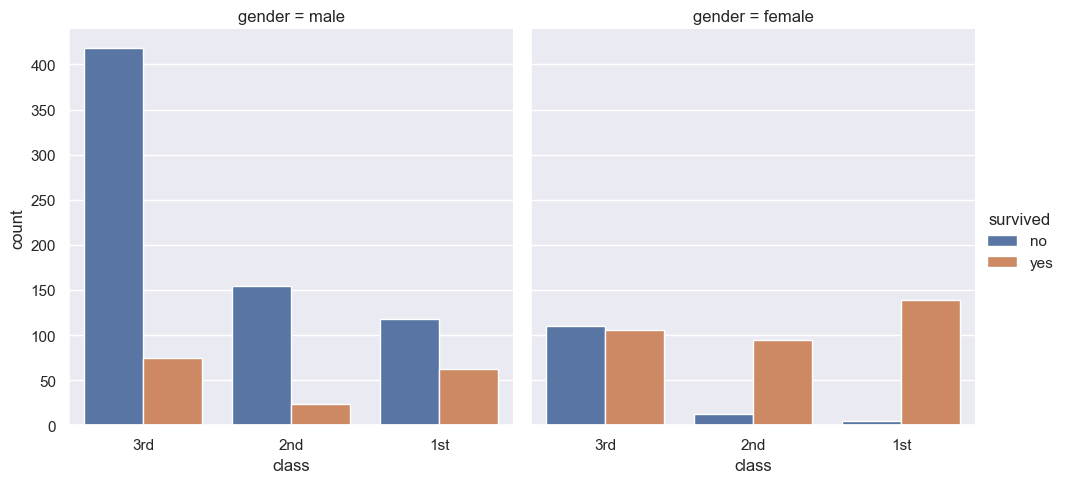

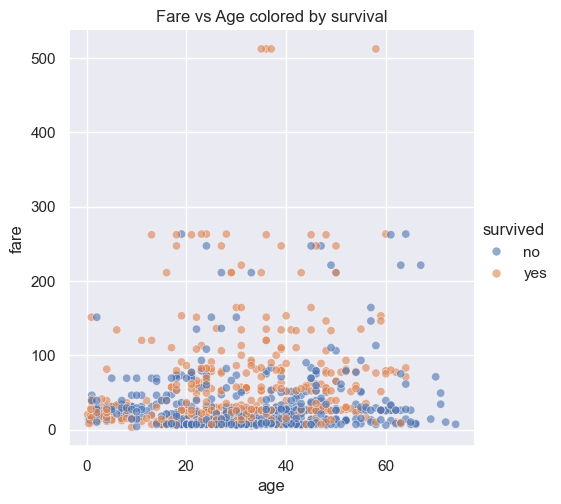

In [6]:
# Survival by gender
sns.catplot(data=passengers, x="gender", hue="survived", kind="count")
plt.title("Survival by gender")
plt.show()

# Survival by class and gender
sns.catplot(data=passengers, x="class", hue="survived", col="gender", kind="count")
plt.show()

# Age vs fare, colored by survival
sns.relplot(data=passengers, x="age", y="fare", hue="survived", alpha=0.6)
plt.title("Fare vs Age colored by survival")
plt.show()
